### پیش بینی قیمت

بخش فروش

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import seaborn as sns
from itertools import product
from sklearn.ensemble import RandomForestRegressor

In [2]:
DATA_PATH = 'Divar.csv'
SEED = 42

FA_DIGITS = str.maketrans({'۰':'0','۱':'1','۲':'2','۳':'3','۴':'4','۵':'5','۶':'6','۷':'7','۸':'8','۹':'9',
                           '٠':'0','١':'1','٢':'2','٣':'3','٤':'4','٥':'5','٦':'6','٧':'7','٨':'8','٩':'9'})
FA_NUM_WORDS = {'یک':1,'دو':2,'سه':3,'چهار':4,'پنج':5,'شش':6,'هفت':7,'هشت':8,'نه':9,'ده':10}
WORD_MAP = {'همکف':'0','زیرزمین':'-1','نوساز':'1403'}
BOOL_MAP = {True:1,False:0,'True':1,'False':0,'true':1,'false':0,'select':1,'unselect':0,'1':1,'0':0}

fa_to_en   = lambda t: np.nan if pd.isna(t) else str(t).strip().translate(FA_DIGITS)
clean_num  = lambda s: pd.to_numeric(s.astype(str).str.strip().str.translate(FA_DIGITS)
                                     .str.replace('+','',regex=False).replace(WORD_MAP), errors='coerce')
normalize_fa = lambda t: '' if pd.isna(t) else re.sub(r'\s+',' ',
    str(t).replace('ي','ی').replace('ك','ک').replace('\u200c',' ').replace('\u200d',' ')).strip().lower()

def parse_rooms(v):
    if pd.isna(v): return np.nan
    s = fa_to_en(v)
    if s in FA_NUM_WORDS: return float(FA_NUM_WORDS[s])
    m = re.search(r'\d+', s)
    if m: return float(m.group())
    for w,n in FA_NUM_WORDS.items():
        if w in s: return float(n)
    return np.nan

def parse_year(v):
    if pd.isna(v): return np.nan
    m = re.search(r'(13\d{2}|14\d{2})', fa_to_en(v))
    return float(m.group()) if m else np.nan

def smooth_te(tr, col, tgt, m=100):
    gm = tr[tgt].mean(); st = tr.groupby(col)[tgt].agg(['count','mean'])
    return (st['count']*st['mean'] + m*gm) / (st['count'] + m)

def kfold_te(tr, col, tgt, m=100):
    out = pd.Series(np.nan, index=tr.index)
    for tri, vai in KFold(5, shuffle=True, random_state=SEED).split(tr):
        out.iloc[vai] = tr.iloc[vai][col].map(smooth_te(tr.iloc[tri], col, tgt, m))
    return out.fillna(tr[tgt].mean())

print("توابع پاکسازی ایجاد شد")

توابع پاکسازی ایجاد شد


In [ ]:
# title description برای استخراج ویژگی‌های کلیدی
KW = {
    'kw_nosaz':['نوساز','نو ساز','کلید نخورده','کلید اول'],
    'kw_renovated':['بازسازی شده','بازسازی کامل','نوسازی شده'],
    'kw_pool':['استخر','سونا','جکوزی'],
    'kw_lobby_guard':['لابی','لوبی','نگهبان','نگهبانی'],
    'kw_urgent':['فوری','زیر قیمت','زیرقیمت','تخفیف','خوش قیمت'],
    'kw_loan':['وام','تسهیلات','مانده وام'],
    'kw_office_use':['اداری','تجاری','مطب','دفتر کار'],
    'kw_good_plan':['خوش نقشه','بدون پرتی','پرتی ندارد','نقشه عالی'],
    'kw_lux':['لوکس','مجلل','لاکچری','سلطنتی'],
    'kw_yard':['حیاط','باغچه','درختکاری','فضای سبز'],
    'kw_roof_duplex':['روف','پنت هاوس','تراس','دوبلکس','تریپلکس'],
    'kw_sea_view':['ویو دریا','دید دریا','رو به دریا','ساحل','نزدیک دریا'],
    'kw_forest':['جنگل','جنگلی','دل جنگل','نزدیک جنگل','میان جنگل'],
    'kw_villa':['ویلا','ویلایی','ویلای','دوبلکس ویلایی'],
    'kw_furnished_t':['مبله کامل','فول مبله','آماده سکونت'],
    'kw_coastal':['ساحلی','خط ساحل','دریا کنار'],
    'kw_mountain':['کوهپایه','کوهستانی','ارتفاعات'],
}

# لود و پاک‌سازی 
print('در حال خواندن دیتا...')
df = pd.read_csv(DATA_PATH, usecols=['cat2_slug','city_slug','neighborhood_slug','price_value',
    'building_size','land_size','rooms_count','construction_year','floor','total_floors_count',
    'location_latitude','location_longitude','has_elevator','has_parking','has_warehouse',
    'has_balcony','title','description'], low_memory=False)
df = df[df['cat2_slug'].isin(['residential-sell','commercial-sell'])].copy()
df['is_commercial'] = (df['cat2_slug']=='commercial-sell').astype(float)
df = df.drop(columns='cat2_slug')

df = df[df['price_value'].between(1e8,5e12) & df['building_size'].between(20,3000)].copy()

text = (df['title'].fillna('')+' '+df['description'].fillna('')).map(normalize_fa)
for n,w in KW.items():
    df[n] = text.str.contains('|'.join(map(re.escape,w)), regex=True, na=False).astype(float)
df['tourist_features'] = df[['kw_sea_view','kw_forest','kw_villa','kw_furnished_t',
                             'kw_coastal','kw_mountain','kw_pool','kw_yard','kw_roof_duplex']].sum(axis=1)
df = df.drop(columns=['title','description'])

df['rooms'] = df['rooms_count'].apply(parse_rooms)
df['age']   = (1404 - df['construction_year'].apply(parse_year)
               .where(lambda s: s.between(1300,1410))).clip(lower=0)
for c in ['floor','total_floors_count','land_size','location_latitude','location_longitude']:
    df[c] = clean_num(df[c])
for c in ['has_elevator','has_parking','has_warehouse','has_balcony']:
    df[c] = df[c].map(BOOL_MAP).astype(float)

df['ppm_listing'] = df['price_value']/df['building_size']
df['has_rooms']   = df['rooms'].notna().astype(float)         
res_mask = df['is_commercial']==0

# سازگاری اتاق فقط برای مسکونی
rooms_consistent = df['rooms'].notna() & ((df['building_size']/df['rooms'].clip(lower=1))<=400)
keep_rooms = (~res_mask) | rooms_consistent

ppm_ok = np.where(res_mask,
                  df['ppm_listing'].between(2e6, 8e8),
                  df['ppm_listing'].between(2e6, 2e9))

df = df[keep_rooms & (~(df['floor']>df['total_floors_count']+2)) &
        ppm_ok & df['price_value'].between(3e8,2e12)]
df = df.drop(columns=['rooms_count','construction_year']).dropna(subset=['city_slug'])
print(f'تمیز: {len(df):,}  (تجاری: {df["is_commercial"].sum():,.0f})')
df['ppm_listing'] = df['price_value']/df['building_size']
df = df[df['rooms'].notna() & ((df['building_size']/df['rooms'].clip(lower=1))<=400) &
        (~(df['floor']>df['total_floors_count']+2)) &
        df['ppm_listing'].between(2e6,8e8) & df['price_value'].between(3e8,2e12)]
print(f'تمیز: {len(df):,}')

# تقسیم و انکدینگ 
train_df, ho    = train_test_split(df, test_size=0.30, random_state=SEED)
val_df, test_df = train_test_split(ho,  test_size=0.50, random_state=SEED)
train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
print(f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')

for d in (train_df, val_df, test_df):
    d['size_bucket']    = pd.cut(d['building_size'], bins=[0,60,90,120,200,400,1e9],
                                 labels=['xs','s','m','l','xl','xxl']).astype(str)
    d['neigh_size_key'] = d['neighborhood_slug'].astype(str)+'_'+d['size_bucket'] # پیش بینی قیمت هر متر 

for col, name in [('city_slug','city'),('neighborhood_slug','neighborhood'),
                  ('neigh_size_key','neigh_size')]:
    for tgt, suf in [('price_value','te'),('ppm_listing','ppm')]:
        train_df[f'{name}_{suf}'] = kfold_te(train_df, col, tgt)
        full = smooth_te(train_df, col, tgt); fb = train_df[tgt].mean()
        for d in (val_df, test_df): d[f'{name}_{suf}'] = d[col].map(full).fillna(fb)
    cnt = train_df[col].value_counts()
    train_df[f'{name}_count'] = train_df[col].map(cnt).fillna(0)
    for d in (val_df, test_df): d[f'{name}_count'] = d[col].map(cnt).fillna(0)

for c in ['rooms','age','floor','total_floors_count','land_size']:
    for typ in (0,1):                                   # 0=مسکونی =1 تجاری
        med = train_df.loc[train_df['is_commercial']==typ, c].median()
        if pd.isna(med): continue                       # تجاری بدون اتاق 
        for d in (train_df, val_df, test_df):
            m = (d['is_commercial']==typ) & d[c].isna()
            d.loc[m, c] = med

for d in (train_df, val_df, test_df):
    d['floor_ratio']      = d['floor']/d['total_floors_count'].replace(0,np.nan)
    d['amenities']        = d[['has_elevator','has_parking','has_warehouse','has_balcony']].sum(axis=1) # امکانات
    d['neigh_city_ratio'] = d['neighborhood_ppm']/d['city_ppm'].replace(0,np.nan)
    d['size_rank_neigh']  = d.groupby('neighborhood_slug')['building_size'].rank(pct=True).fillna(0.5)
    d['lux_pool']  = d['kw_pool']
    d['lux_guard'] = d['kw_lobby_guard']
    d['lux_big']   = ((d['size_rank_neigh'] > 0.9) | d['size_bucket'].isin(['xl','xxl'])).astype(float)
    d['lux_ppm']   = (d['neigh_city_ratio'] > 1.3).astype(float)
    d['lux_decl']  = ((d['kw_lux'] == 1) | (d['kw_roof_duplex'] == 1)).astype(float)
    d['luxury_score'] = (d['lux_pool'] + d['lux_guard'] + d['lux_big'] +
                         d['lux_ppm'] + d['lux_decl']).astype(int)
    d['age_x_rooms']         = d['age']*d['rooms']
    d['size_x_has_elevator'] = d['building_size']*d['has_elevator']
    d['size_x_ppm']          = d['building_size']*d['neighborhood_ppm']
    d['size_x_ppm2']         = d['building_size']*d['neigh_size_ppm']
    d['size_per_room']       = d['building_size']/d['rooms'].replace(0,np.nan)
    d['comm_x_ppm']   = d['is_commercial']*d['size_x_ppm']   # ضریب جدا برای تجاری

FEATURES = ['building_size','land_size','rooms','age','floor','total_floors_count',
    'location_latitude','location_longitude','has_elevator','has_parking','has_warehouse',
    'has_balcony','city_te','city_ppm','city_count','neighborhood_te','neighborhood_ppm',
    'neighborhood_count','neigh_size_ppm','floor_ratio','amenities','neigh_city_ratio',
    'size_rank_neigh','luxury_score','age_x_rooms','size_x_has_elevator','size_x_ppm',
    'size_x_ppm2','size_per_room','tourist_features','kw_nosaz','kw_renovated','kw_urgent',
    'kw_loan','kw_office_use','kw_good_plan','kw_lobby_guard','kw_forest','kw_villa',
    'is_commercial','has_rooms','comm_x_ppm']      

X_train, X_val, X_test = (d[FEATURES].copy() for d in (train_df, val_df, test_df))
y_train, y_val, y_test = (np.log1p(d['price_value']) for d in (train_df, val_df, test_df))

در حال خواندن دیتا...
تمیز: 423,826  (تجاری: 19,911)
تمیز: 422,065
train=295,445  val=63,310  test=63,310


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# گریدهای جست‌وجو 
HGB_GRID = [dict(learning_rate=lr, max_leaf_nodes=int(ln),
                 min_samples_leaf=int(ms), l2_regularization=l2)
            for lr, ln, ms, l2 in product([0.05,0.08],[63,127],[30,60],[1.0,5.0])]   
RF_GRID  = [dict(n_estimators=400, max_depth=md, min_samples_leaf=int(ms))
            for md, ms in product([None,24],[10,30])]                                 

results, fitted = [], {}

print('Grid Search HistGBR(advanced_model)')
for i, p in enumerate(HGB_GRID, 1):
    m = HistGradientBoostingRegressor(max_iter=2000, max_bins=255, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=60, random_state=SEED, **p)
    m.fit(X_train, y_train)
    v = r2_score(y_val, m.predict(X_val))
    fitted[('HistGBR', i)] = m
    results.append({'family':'HistGBR','id':i,'val_R2':v, **p})
    print(f'  [{i:2d}/{len(HGB_GRID)}] val_R2={v:.4f}  {p}')

print('Grid Search RandomForest(basic_model)')
for j, p in enumerate(RF_GRID, 1):
    m = RandomForestRegressor(n_jobs=-1, random_state=SEED, **p)
    m.fit(X_train, y_train)
    v = r2_score(y_val, m.predict(X_val))
    fitted[('RF', j)] = m
    results.append({'family':'RF','id':j,'val_R2':v, **p})
    print(f'  [{j:2d}/{len(RF_GRID)}] val_R2={v:.4f}  {p}')

# لیدربورد و انتخاب برنده 
res = pd.DataFrame(results).sort_values('val_R2', ascending=False)
print('\nلیدربورد):')
print(res.round(4).to_string(index=False))

best = res.iloc[0]
if best['family'] == 'HistGBR':
    bp = {'learning_rate':float(best['learning_rate']), 'max_leaf_nodes':int(best['max_leaf_nodes']),
          'min_samples_leaf':int(best['min_samples_leaf']), 'l2_regularization':float(best['l2_regularization'])}
    model = HistGradientBoostingRegressor(max_iter=6000, max_bins=255, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=100, random_state=SEED, **bp)
    model.fit(X_train, y_train)
elif best['family'] == 'GB':
    bp = {k2:v for k2,v in best.items() if k2 not in ('family','id','val_R2')}
    model = fitted[('GB', int(best['id']))]
else:
    bp = {k2:v for k2,v in best.items() if k2 not in ('family','id','val_R2')}
    model = fitted[('RF', int(best['id']))]
print(f'\nبرنده: {best["family"]} | val_R2={best["val_R2"]:.4f} | پارامترها: {bp}')

Grid Search HistGBR(advanced_model)
  [ 1/16] val_R2=0.8203  {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 30, 'l2_regularization': 1.0}
  [ 2/16] val_R2=0.8204  {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 30, 'l2_regularization': 5.0}
  [ 3/16] val_R2=0.8210  {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 1.0}
  [ 4/16] val_R2=0.8206  {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 5.0}
  [ 5/16] val_R2=0.8223  {'learning_rate': 0.05, 'max_leaf_nodes': 127, 'min_samples_leaf': 30, 'l2_regularization': 1.0}
  [ 6/16] val_R2=0.8225  {'learning_rate': 0.05, 'max_leaf_nodes': 127, 'min_samples_leaf': 30, 'l2_regularization': 5.0}
  [ 7/16] val_R2=0.8234  {'learning_rate': 0.05, 'max_leaf_nodes': 127, 'min_samples_leaf': 60, 'l2_regularization': 1.0}
  [ 8/16] val_R2=0.8231  {'learning_rate': 0.05, 'max_leaf_nodes': 127, 'min_samples_leaf': 60, 'l2_regularization


          R2     MSE     MAE
Val   0.8236  0.3975  0.1552
Test  0.8222  0.3936  0.1549


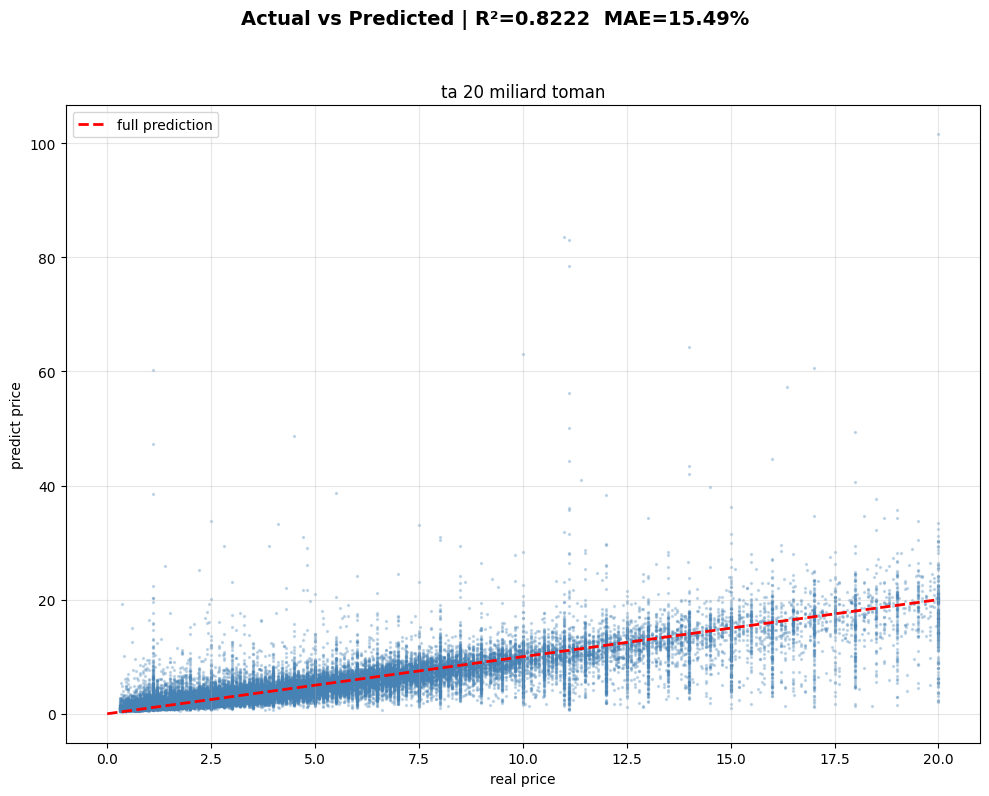

In [16]:
# متریک‌های نهایی 
def eval_metrics(X, y_log):
    pl = model.predict(X); pr, ac = np.expm1(pl), np.expm1(y_log)
    ape = np.abs(ac-pr)/ac
    return dict(R2=r2_score(y_log, pl), MSE=mean_squared_error(y_log, pl)**.5,
                MAE=np.median(ape))

m_val, m_test = eval_metrics(X_val, y_val), eval_metrics(X_test, y_test)
print('\n' + '='*70)
print(pd.DataFrame({'Val': m_val, 'Test': m_test}).T.round(4).to_string())
print('='*70)
# نمودار Actual vs Predicted 
pred, actual = np.expm1(model.predict(X_test)), np.expm1(y_test)  

fig, ax = plt.subplots(figsize=(10, 8))                            
fig.suptitle(f'Actual vs Predicted | R²={m_test["R2"]:.4f}  MAE={m_test["MAE"]:.2%}',
             fontsize=14, fontweight='bold', y=0.99)

cap = 2e10; k = actual < cap
ax.scatter(actual[k]/1e9, pred[k]/1e9, s=2, alpha=0.25, c='steelblue')
lims = [0, cap/1e9]
ax.plot(lims, lims, 'r--', lw=2, label='full prediction')
ax.set_xlabel('real price')
ax.set_ylabel('predict price')
ax.set_title('ta 20 miliard toman')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()